The first step is to write a function that can track the same eigenvalues and eigenvectors for a dynamical matrix. 
Which I found here : https://github.com/bmachiel/python-nport/blob/master/nport/eigenshuffle.py
It had some issues and was not stable which I changed it a little bit and it worked. 

In [1]:
from eigenshuffle import eigenshuffle

an example to check if it works

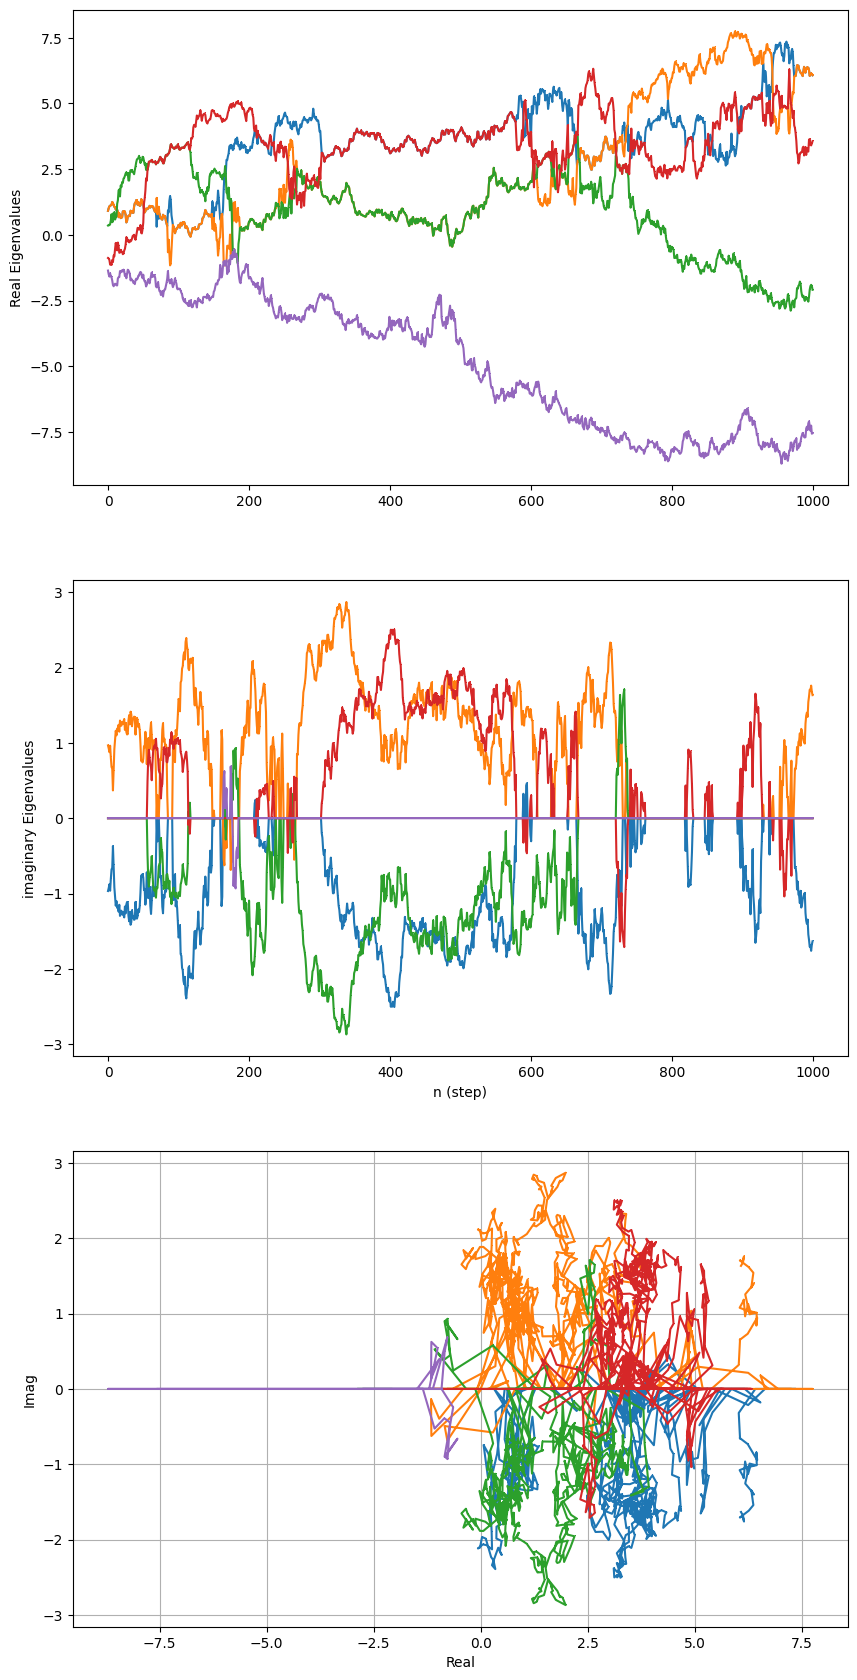

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000 # number of steps in dynamic
M = 5 # Dimension of the matrix
noise = 0.1 # rate of change for matrix at each step 

A = np.random.randn(M, M)
A_save = np.zeros([N, M, M])

for i in range(N):
    A_save[i, :, :] = A
    A = A + noise*np.random.randn(M, M)
    
Dseq, Vseq  = eigenshuffle(Asequence=A_save)

plt.figure(figsize=(10,21))
plt.subplot(3,1,1)
plt.ylabel("Real Eigenvalues")
for m in range(M):
    plt.plot(Dseq[:, m].real, ',-')


plt.subplot(3,1,2)
plt.ylabel("imaginary Eigenvalues")
plt.xlabel("n (step)")
for m in range(M):
    plt.plot(Dseq[:, m].imag, ',-')

plt.subplot(3,1,3)
for m in range(M):
    plt.plot(Dseq[:, m].real, Dseq[:, m].imag, ',-')
plt.xlabel("Real")
plt.ylabel("Imag")
plt.grid()

plt.show()


We need to understand ornstein-uhlenberg proccess and ito calculus! 

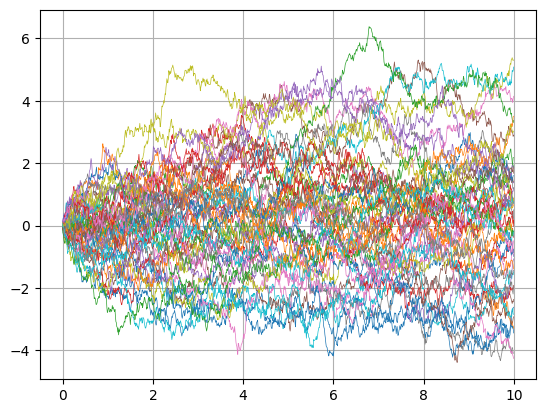

In [4]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.01
T = 10
t = np.arange(0, T, dt)



for repeat in range(50):
    x = np.random.uniform(-0.1, 0.1)
    x_save = np.zeros(len(t))
    
    for i in range(len(t)):
        x_save[i] = x
        x = x  - 0.1*x*dt + np.random.normal(loc= 0, scale = np.sqrt(dt)) 
    
        
    plt.plot(t, x_save, linewidth=0.5)
    
plt.grid()
plt.show()

Now we need to understand what is first order low pas filter! 

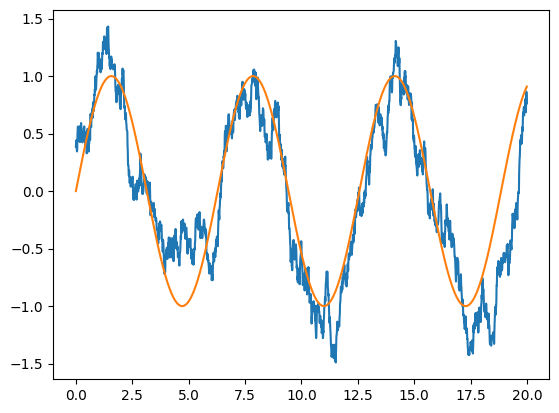

In [5]:
dt = 0.01 
T = 20

t = np.arange(0, T, dt)
N = len(t)

y = np.sin(t) 

def OUprocces(gamma, g, dt, T):
    x = 0
    N = int(T/dt)
    x_array = np.zeros(N)
        
    for i in range(int(3/gamma/dt)):
        x = x - gamma*x*dt + g*np.random.normal()*np.sqrt(dt)
    
    for i in range(N):
        x_array[i] = x
        x = x - gamma*x*dt + g*np.random.normal()*np.sqrt(dt)

    return x_array
    
noise = OUprocces(gamma=1, g = 0.5, dt = dt, T = T)

plt.plot(t, y + noise)
plt.plot(t, y)
plt.show()

Ok, now an interesting question arises! What is the fourier spectrum of a white or wiener process? (I don't know the difference between white and wiener yet! :))) )


## Wave in a 1D box!

In [7]:
# import matplotlib.pyplot as plt
# import numpy as np

# import matplotlib.animation as animation

# L, c = 1, 1
# k, w = 2*np.pi/L, k*c

# N = 10 # maximum number of waves
# g = np.zeros(N)
# for i in range(N):
#     g[i] = 1

# T = 20
# dt = 0.01
# dL = 0.01
# x = np.arange(0, L, dL)

# def y(x, t):
#     global k, w, g, N
#     return np.sum([np.sin(n*k*x)*np.cos(w*n*t)*g[n-1] for n in range(1, N+1)], axis=0)


# fig, ax = plt.subplots()
# ax.grid()
# t = np.arange(0, T, dt)

# line = ax.plot(x, y(x, t[0]))[0]
# # ax.set(xlim=[0, 3], ylim=[-4, 10], xlabel='Time [s]', ylabel='Z [m]')
# # ax.legend()


# def update(frame):
#     # update the line plot:
#     line.set_ydata(y(x, t[frame]))
    
#     return line


# ani = animation.FuncAnimation(fig=fig, func=update, frames=int(T/dt), interval=200)
# ani.save('s.gif')

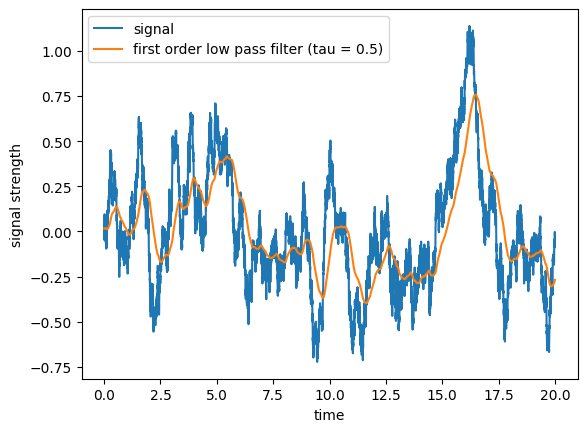

In [15]:
dt, T = 0.001, 20
tau = 0.5

t = np.arange(0, T, dt)
x = OUprocces(gamma=1, g = 0.5, dt=dt, T=T)
y = np.zeros(len(x))
y[0] = x[0]

for i in range(0, len(x)-1):
    y[i+1] = y[i] + (x[i] - y[i])*dt/tau

plt.plot(t, x, label='signal')
plt.plot(t, y, label='first order low pass filter (tau = ' + str(tau) + ')')
plt.xlabel('time')
plt.ylabel('signal strength')
plt.legend()
plt.show()